# Model B₂ — Jockeying from class-1 only on $\widetilde{S}$
### $\gamma_1 > 0$,  $\gamma_2 = \theta_1 = \theta_2 = 0$

Class-1 customers jockey to class-2 at per-customer rate $\gamma_1$, but class-2
customers never move back. In state space $\widetilde{S}$, jockeying increases $n_2$
at fixed $n$, so mass flows *up* within each column toward the diagonal $n_2=n$.

The fundamental equation reduces to a **first-order linear ODE in $x$** (thesis §6.1.2),
which admits a closed-form integral solution. Here we analyse it numerically.

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, simulate_tilde,
    convert_S_to_Stilde,
    P_tilde, marginals_tilde, diagnostics_tilde,
    P_tilde_approx_modelA, y_star,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

# ── shared plotting helpers ───────────────────────────────────────────────────

def tilde_heatmap(ax, pi_tilde, title, nmax=12, log=False, vmin=None, vmax=None):
    grid = pi_tilde[:nmax+1, :nmax+1].copy()
    n2i, ni = np.indices(grid.shape)
    grid[n2i > ni] = np.nan
    if log:
        grid = np.where(grid > 0, grid, np.nan)
        vm  = vmin or 1e-6
        vM  = vmax or float(np.nanmax(grid))
        im  = ax.imshow(grid, origin="lower", cmap="viridis",
                        norm=LogNorm(vmin=vm, vmax=vM))
    else:
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       vmin=vmin or 0, vmax=vmax or float(np.nanmax(grid)))
    ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$n_2$")
    ax.set_title(title)
    ax.plot([0, nmax], [0, nmax], "w--", lw=0.8, alpha=0.6)
    return im

def ppgf_panel(ax, pi_tilde, p, ns=(1,2,3,5,8), show_approx=False, label_suffix=""):
    y = np.linspace(0.0, 1.0, 201)
    cols = plt.cm.viridis(np.linspace(0.15, 0.9, len(ns)))
    for n, c in zip(ns, cols):
        ax.plot(y, P_tilde(y, n, pi_tilde), color=c, lw=2.0,
                label=rf"$n={n}${label_suffix}")
        if show_approx:
            ax.plot(y, P_tilde_approx_modelA(y, n, p), color=c,
                    lw=1.3, ls="--", alpha=0.7)
    ax.set_xlabel(r"$y$"); ax.set_ylabel(r"$\widetilde{P}(y,n)$")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

def marginals_panel(ax, pi_tilde, kmax=14):
    m = marginals_tilde(pi_tilde)
    k = np.arange(min(kmax+1, len(m["pi_n1"])))
    ax.bar(k - 0.2, m["pi_n1"][:len(k)], 0.4, label=r"$\pi(n_1)$",
           color="#1f3a93", alpha=0.85)
    ax.bar(k + 0.2, m["pi_n2"][:len(k)], 0.4, label=r"$\pi(n_2)$",
           color="#c0392b", alpha=0.85)
    ax.set_xlabel("queue count"); ax.set_ylabel("probability")
    ax.legend(); ax.grid(alpha=0.3)

def metrics_row(name, p, r):
    d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    print(f"  {name:<28} pi_0={r['pi_idle']:.4f}  P(busy)={d['P_busy']:.4f}"
          f"  E[N1]={d['E_n1']:.3f}  E[N2]={d['E_n2']:.3f}"
          f"  E[N]={d['E_n']:.3f}  throughput={d['throughput']:.4f}")

In [2]:
p_A  = Params(0.3, 0.4, 1.0)
p_B2 = Params(0.3, 0.4, 1.0, gamma1=0.8)

r_A  = solve_exact_tilde(p_A,  n_max=60)
r_B2 = solve_exact_tilde(p_B2, n_max=60)

print("Cross-validate (jockeying preserves total load):")
for name, pm, r in [("Model A", p_A, r_A), ("Model B2", p_B2, r_B2)]:
    metrics_row(name, pm, r)

Cross-validate (jockeying preserves total load):
  Model A                      pi_0=0.3000  P(busy)=0.7000  E[N1]=0.300  E[N2]=1.333  E[N]=1.633  throughput=0.7000
  Model B2                     pi_0=0.3000  P(busy)=0.7000  E[N1]=0.124  E[N2]=1.509  E[N]=1.633  throughput=0.7000


## 1. Joint distribution — mass migration toward the diagonal

$\gamma_1>0$ moves class-1 customers into the class-2 queue (increasing $n_2$ at
fixed $n$). The mass in each column shifts *up* toward $n_2=n$, making the diagonal
more prominent and the lower triangle sparser.

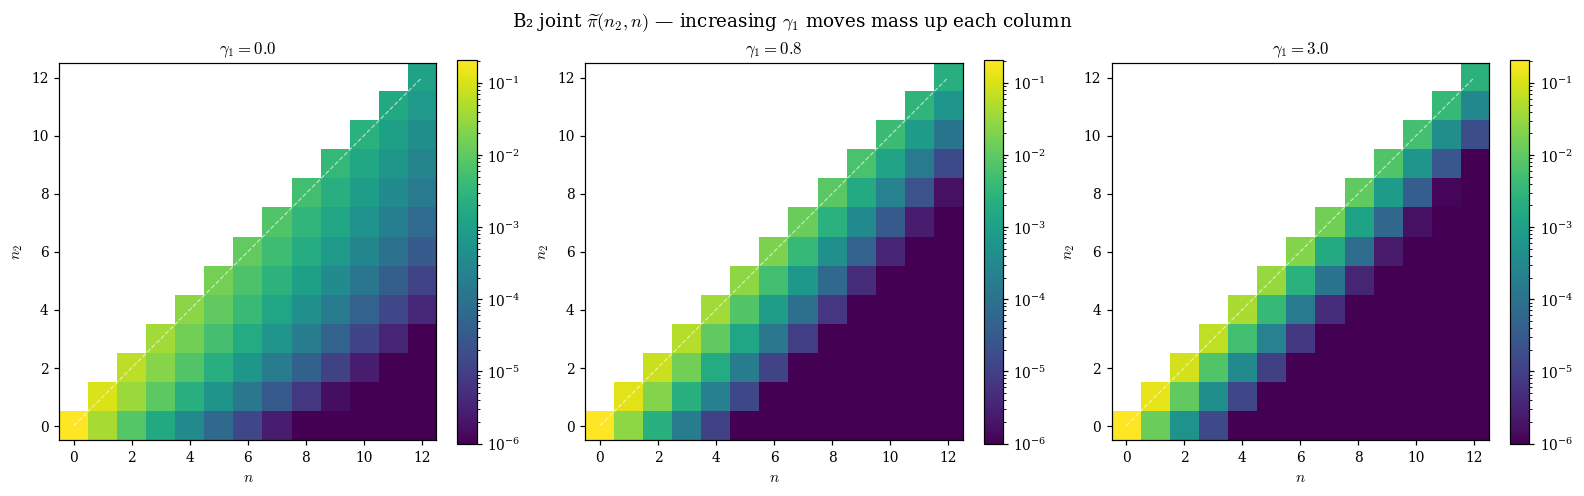

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
g_vals_plot = [0.0, 0.8, 3.0]
for ax, g1 in zip(axes, g_vals_plot):
    p_g = Params(0.3, 0.4, 1.0, gamma1=g1)
    r_g = solve_exact_tilde(p_g, n_max=60)
    im  = tilde_heatmap(ax, r_g["pi_tilde"], rf"$\gamma_1={g1}$", log=True)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(r"B₂ joint $\widetilde{\pi}(n_2, n)$ — increasing $\gamma_1$ moves mass up each column")
fig.tight_layout()

## 2. Within-column profile evolution

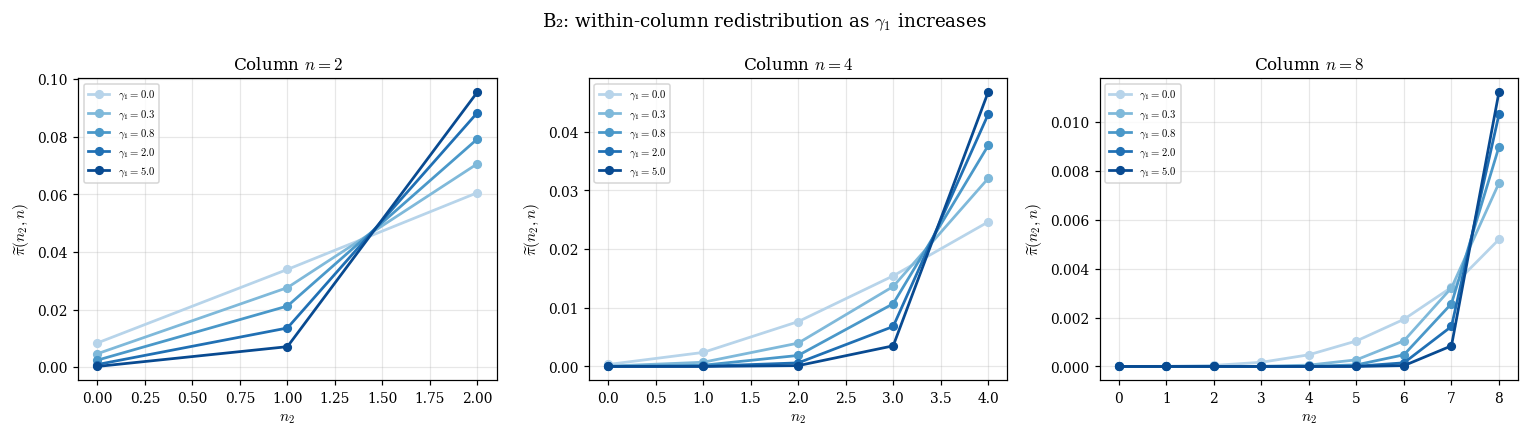

In [4]:
g_sweep = [0.0, 0.3, 0.8, 2.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
for ax, n in zip(axes, [2, 4, 8]):
    n2vals = np.arange(n + 1)
    cols = plt.cm.Blues(np.linspace(0.3, 0.9, len(g_sweep)))
    for g1, c in zip(g_sweep, cols):
        r_g = solve_exact_tilde(Params(0.3, 0.4, 1.0, gamma1=g1), n_max=60)
        col = np.array([r_g["pi_tilde"][n2, n] for n2 in n2vals])
        ax.plot(n2vals, col, "o-", color=c, lw=1.8, ms=5,
                label=rf"$\gamma_1={g1}$")
    ax.set_xlabel(r"$n_2$"); ax.set_ylabel(r"$\widetilde{\pi}(n_2, n)$")
    ax.set_title(rf"Column $n={n}$"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle(r"B₂: within-column redistribution as $\gamma_1$ increases")
fig.tight_layout()

## 3. PPGF and mean queue lengths vs $\gamma_1$

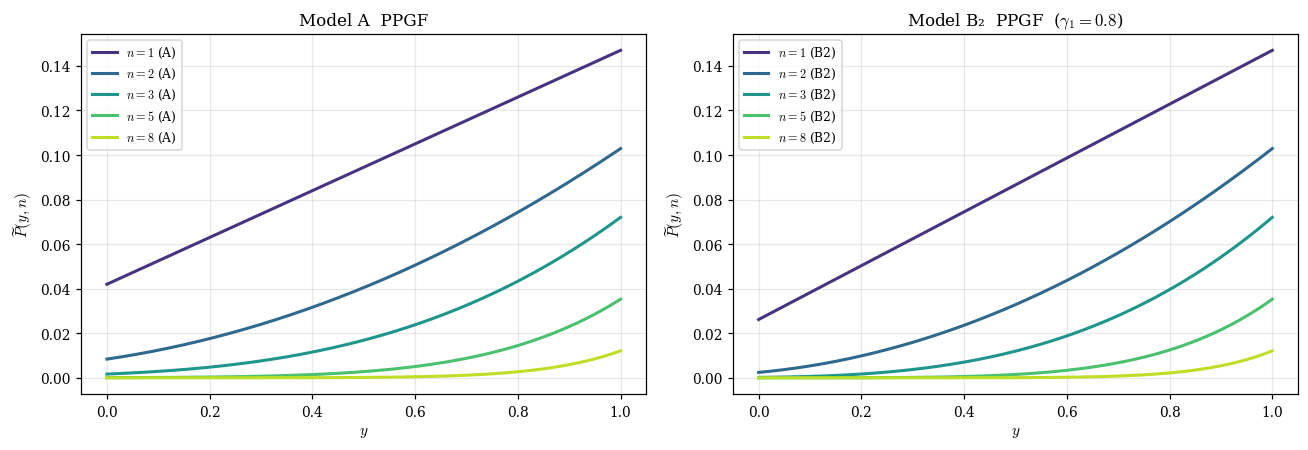

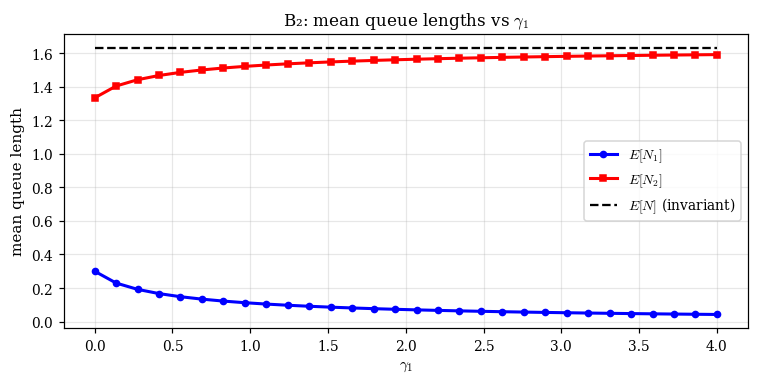

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ppgf_panel(axes[0], r_A["pi_tilde"],  p_A,  label_suffix=" (A)")
ppgf_panel(axes[1], r_B2["pi_tilde"], p_B2, label_suffix=" (B2)")
axes[0].set_title("Model A  PPGF"); axes[1].set_title(r"Model B₂  PPGF  ($\gamma_1=0.8$)")
fig.tight_layout()

g_vals = np.linspace(0.0, 4.0, 30)
En1, En2 = [], []
for g in g_vals:
    r_g = solve_exact_tilde(Params(0.3, 0.4, 1.0, gamma1=g), n_max=60)
    d   = diagnostics_tilde(Params(0.3, 0.4, 1.0, gamma1=g), r_g["pi_idle"], r_g["pi_tilde"])
    En1.append(d["E_n1"]); En2.append(d["E_n2"])

fig2, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(g_vals, En1, "b-o", ms=4, lw=2, label=r"$E[N_1]$")
ax.plot(g_vals, En2, "r-s", ms=4, lw=2, label=r"$E[N_2]$")
ax.plot(g_vals, np.array(En1)+np.array(En2), "k--", lw=1.5, label=r"$E[N]$ (invariant)")
ax.set_xlabel(r"$\gamma_1$"); ax.set_ylabel("mean queue length")
ax.set_title(r"B₂: mean queue lengths vs $\gamma_1$")
ax.legend(); ax.grid(alpha=0.3)
fig2.tight_layout()